# GEA — Event-Scoring Walkthrough

**Component:** GEA (Geopolitical-Event Analytics)

This notebook walks through the GEA event-scoring pipeline: it loads the bundled synthetic public-style feeds (sanctions-style listings, AIS vessel positions, weather observations), assembles per-candidate-event features, scores each candidate, and emits `supply_disruption_event` records conforming to the SD-MAC schema registry.

> **Synthetic data only.** Every dataset used in this notebook is *synthetic illustrative data generated for demonstration*. It is **NOT** real agency data and is **NOT** derived from any proprietary or employer source. The notebook performs no network access and uses only public-style, open-source components.

In [1]:
import sys
from pathlib import Path

# Put the oefaf-platform repository root on sys.path so the platform
# component packages (gea, cricat, sdmac, shared) import cleanly no matter
# what working directory this notebook is executed from.
_REPO_ROOT = Path.cwd()
while not (_REPO_ROOT / 'sdmac' / 'schema_registry').is_dir():
    if _REPO_ROOT == _REPO_ROOT.parent:
        raise RuntimeError('Could not locate the oefaf-platform repo root.')
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
print('repo root located:', _REPO_ROOT.name)

repo root located: oefaf-platform


## 1. Load synthetic feeds and assemble candidate-event features

`gea.ingestion.loaders.assemble_event_features` reads the three bundled synthetic GEA fixtures and derives one transparent, normalized feature row per candidate region.

In [2]:
import pandas as pd
from gea.ingestion.loaders import (
    assemble_event_features,
    load_ais_positions,
    load_sanctions_events,
    load_weather_observations,
)

sanctions = load_sanctions_events()
ais = load_ais_positions()
weather = load_weather_observations()
print('synthetic sanctions rows:', len(sanctions))
print('synthetic AIS rows:      ', len(ais))
print('synthetic weather rows:  ', len(weather))

features = assemble_event_features(sanctions, ais, weather)
print('\ncandidate events:', len(features))
features[[
    'region_iso', 'commodity', 'sanctions_intensity',
    'ais_disruption', 'weather_stress', 'n_sources',
]]

synthetic sanctions rows: 24
synthetic AIS rows:       60
synthetic weather rows:   72

candidate events: 7


,region_iso,commodity,sanctions_intensity,ais_disruption,weather_stress,n_sources
0,AUS,crude_oil,0.6,0.183333,0.263473,3
1,CHN,crude_oil,0.4,0.183333,0.312638,3
2,EUR,crude_oil,0.6,0.183333,0.227422,3
3,NGA,crude_oil,1.0,0.183333,0.275329,3
4,RUS,crude_oil,1.0,0.183333,0.296704,3
5,SAU,crude_oil,0.8,0.183333,0.210177,3
6,USA,crude_oil,0.4,0.183333,0.302355,3


## 2. Run the transparent scorer and emit schema records

`gea.scoring.scorer.build_events` scores each candidate with a fixed-weight, fully inspectable aggregation (severity) and a logistic evidence-agreement signal (confidence), then emits complete `supply_disruption_event` records.

In [3]:
from gea.scoring.scorer import FEATURE_WEIGHTS, build_events

print('severity feature weights (sum = 1.0):', FEATURE_WEIGHTS)

events = build_events(features)
print('emitted supply_disruption_event records:', len(events))

events_df = pd.DataFrame(events)
events_df[[
    'event_id', 'region_iso', 'commodity',
    'severity_score', 'confidence', 'source_categories',
]]

severity feature weights (sum = 1.0): {'sanctions_intensity': 0.4, 'ais_disruption': 0.35, 'weather_stress': 0.25}
emitted supply_disruption_event records: 7


,event_id,region_iso,commodity,severity_score,confidence,source_categories
0,GEA-EVT-0000,AUS,crude_oil,0.370,0.746,"[ais, sanctions, weather]"
1,GEA-EVT-0001,CHN,crude_oil,0.302,0.729,"[ais, sanctions, weather]"
2,GEA-EVT-0002,EUR,crude_oil,0.361,0.742,"[ais, sanctions, weather]"
3,GEA-EVT-0003,NGA,crude_oil,0.533,0.790,"[ais, sanctions, weather]"
4,GEA-EVT-0004,RUS,crude_oil,0.538,0.792,"[ais, sanctions, weather]"
5,GEA-EVT-0005,SAU,crude_oil,0.437,0.762,"[ais, sanctions, weather]"
6,GEA-EVT-0006,USA,crude_oil,0.300,0.727,"[ais, sanctions, weather]"


### Inspect one full emitted record

Each record carries every `supply_disruption_event` field. The `public_evidence_refs` are clearly illustrative `example.org` placeholders — not real agency URLs presented as real.

In [4]:
import json

print(json.dumps(events[0], indent=2))

{
  "event_id": "GEA-EVT-0000",
  "detected_at_utc": "2026-01-26T04:00:00Z",
  "commodity": "crude_oil",
  "region_iso": "AUS",
  "source_categories": [
    "ais",
    "sanctions",
    "weather"
  ],
  "severity_score": 0.37,
  "confidence": 0.746,
  "public_evidence_refs": [
    "https://example.org/synthetic-evidence/crude_oil/AUS/0000/1",
    "https://example.org/synthetic-evidence/crude_oil/AUS/0000/2"
  ]
}


## 3. Confirm every emitted record conforms to the registry schema

`shared.utilities.schema_loader.validate_record` converts the registry YAML to JSON Schema and validates each record.

In [5]:
from shared.utilities.schema_loader import validate_record

all_ok = all(
    validate_record(rec, 'supply_disruption_event') for rec in events
)
print('all', len(events), 'records valid against supply_disruption_event:', all_ok)

all 7 records valid against supply_disruption_event: True


## 4. Severity bar chart

A simple bar of severity per emitted event (synthetic data).

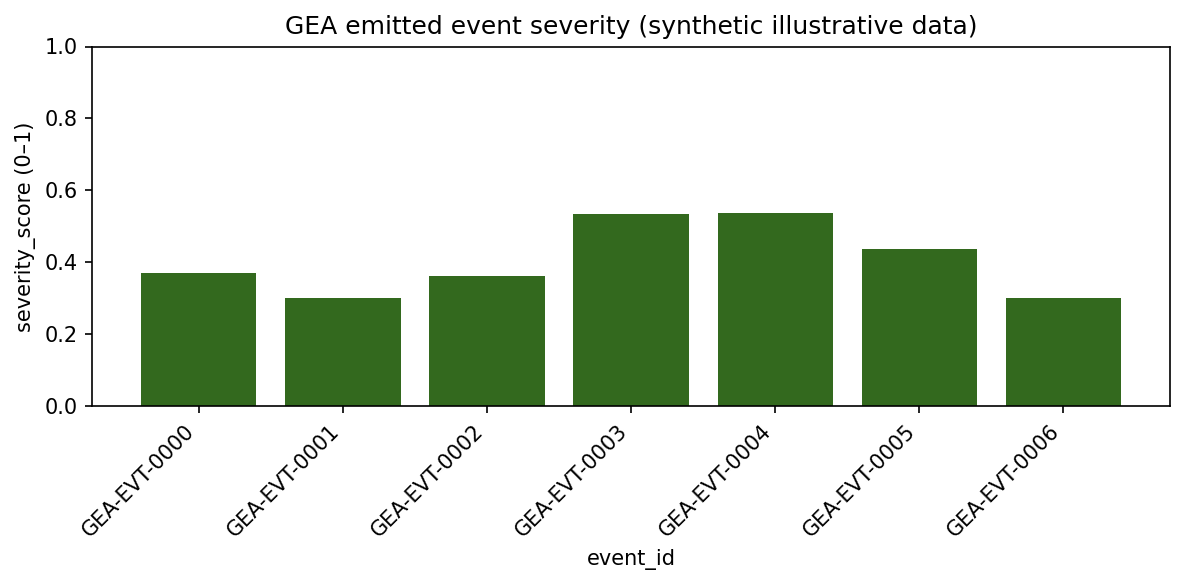

chart rendered for 7 synthetic events


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.bar(events_df['event_id'], events_df['severity_score'], color='#33691e')
ax.set_ylim(0, 1)
ax.set_ylabel('severity_score (0–1)')
ax.set_xlabel('event_id')
ax.set_title('GEA emitted event severity (synthetic illustrative data)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('chart rendered for', len(events_df), 'synthetic events')

---

**Recap.** The pipeline loaded synthetic public-style feeds, assembled candidate-event features, scored them with transparent logic, emitted schema-conformant `supply_disruption_event` records, and validated every record against the SD-MAC schema registry. All data shown is synthetic illustrative data; no proprietary or employer content is used.